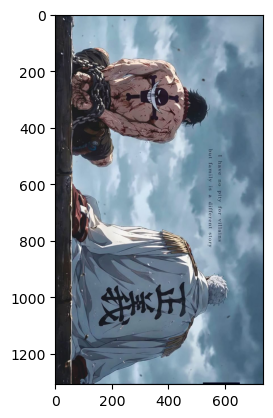

In [50]:
import matplotlib.pyplot as plt
from numba import cuda
import numpy as np
import time
img = plt.imread(r"C:\Users\lapla\OneDrive\Pictures\ace.jpg")
height, width, channels = img.shape
pixels = img[:, :, :3].reshape(height * width, 3)
plt.imshow(img)

CPU execution time: 0.0027 seconds


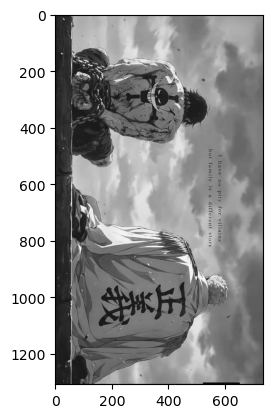

In [51]:
def grayscale_cpu(pixels):
     result = np.empty_like(pixels)
     for i in range(len(pixels)):
          r, g, b = pixels[i]
          gray = (float(r) + float(g) + float(b)) / 3
          result[i] = (gray, gray, gray)
     return result
gray_pixels = grayscale_cpu(pixels)
start_time = time.time()
gray_image = gray_pixels.reshape(height, width, 3)
end_time = time.time()
print(f"CPU execution time: {end_time - start_time:.4f} seconds")
plt.imshow(gray_image)   
plt.show()


GPU execution time: 0.2533 seconds


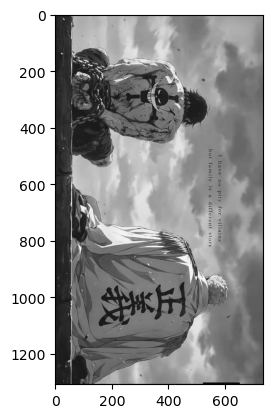

In [52]:
@cuda.jit
def grayscale_gpu(src, dst):
    # where are we in the input?
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
    dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g
src_gpu = cuda.to_device(pixels)
dst_gpu = cuda.device_array_like(src_gpu)
threads_per_block = 64
blocks = (len(pixels) + threads_per_block - 1) // threads_per_block
start_time = time.time()
grayscale_gpu[blocks, threads_per_block](src_gpu, dst_gpu)
end_time = time.time()
print(f"GPU execution time: {end_time - start_time:.4f} seconds")

result = dst_gpu.copy_to_host()
plt.imshow(result.reshape(height, width, 3))
plt.show()


GPU execution time: 0.0043 seconds


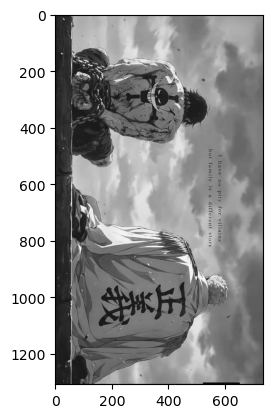

In [53]:
src_gpu = cuda.to_device(pixels)
dst_gpu = cuda.device_array_like(src_gpu)
threads_per_block = 128
blocks = (len(pixels) + threads_per_block - 1) // threads_per_block
start_time = time.time()
grayscale_gpu[blocks, threads_per_block](src_gpu, dst_gpu)
end_time = time.time()
print(f"GPU execution time: {end_time - start_time:.4f} seconds")

result = dst_gpu.copy_to_host()
plt.imshow(result.reshape(height, width, 3))
plt.show()